**Explicit vs Implicit — 1D Heat Equation**

finite difference descretizations for ∂T/∂t = α ∂²T/∂x²

discretize on uniform grid: xᵢ = i·Δx, tⁿ = n·Δt, with Tᵢⁿ ≈ T(xᵢ, tⁿ)

second spatial derivative:

∂²T/∂x² ≈ [ T[i+1] − 2·T[i] + T[i-1] ] / (Δx)²

I am going to compare when to evaluate this: whether at time n (explicit) or n+1 (implicit)

**Explicit**

[ T[i]^(n+1) − T[i]^n ] / Δt = α · [ T[i+1]^n − 2T[i]^n + T[i-1]^n ] / (Δx)²

Let λ = α·Δt/(Δx)²

So then:
T[i]^(n+1) = r·T[i+1]^n + (1−2r)·T[i]^n + r·T[i-1]^n

This is conditionally stable for when λ <= 1/2. So Δt <= (Δx)²/(2α)

**Implicit**

[ T[i]^(n+1) − T[i]^n ] / Δt = α · [ T[i+1]^(n+1) − 2T[i]^(n+1) + T[i-1]^(n+1) ] / (Δx)²

−λ·T[i-1]^(n+1) + (1+2λ)·T[i]^(n+1) − λ·T[i+1]^(n+1) = T[i]^n

This will always be stable

In [4]:
'''
FINITE DIFFERENCE 1D Heat Equation

Domain x in [-1,1].

Discretize with 201 Points. dx = 1/200.
'''

import numpy as np
from scipy.linalg import solve_banded #solves linear equation for me

#make the grid
N = 201
x = np.linspace(-1,1,N)
dx = 1 / 200

# using lambda as param instead of time now
alpha = 0.01
l = 0.4
dt = l * dx **2 / alpha

# initial condition
T_0 = np.exp(-(x+0.5)**2 / 0.001)

def solve_explicit(T_new, l, N):
    T_prev = T_new.copy()

    for i in range(N):
        T_new[1:-1] = T_prev[1:-1] + r * (T_prev[2:] - 2*T_prev[1:-1] + T_prev[:-2])

        # neumann boundary conditions
        # bounday point equals teh neighbor so the slpoe is 0
        T_new[0] =  0
        T_new[-1] = 0
        T_prev = T_new
    
    return T_prev

#setting up linear system where A is triadiogonal to solve
def build_tridiag(N, r):
    ab = np.zeros((3, N))
    ab[0, 1:]  = -r          # upper diag
    ab[1, :]   =  1 + 2*r    # main diag
    ab[2, :-1] = -r          # lower diag
    return ab

def solve_implicit(T_new, l, N):
    # use matrix to solve every step !!!
    T_prev = T_new.copy()
    N = len(T_prev) - 2 #interior nodes
    ab = build_tridiag(N, l) #build A

    for i in range(N):
        b = T_prev[1:-1].copy()
        b[0]  += r * T_prev[0] #left boundary condition
        b[-1] += r * T_prev[-1] #right boundary condition
        T_prev[1:-1] = solve_banded((1, 1), ab, b)
        T_prev[0] = 0
        T_prev[-1] = 0
    
    return T_prev


In [6]:
T_exp = solve_explicit(T_0, l,  N)
T_imp = solve_implicit(T_0, l, N)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


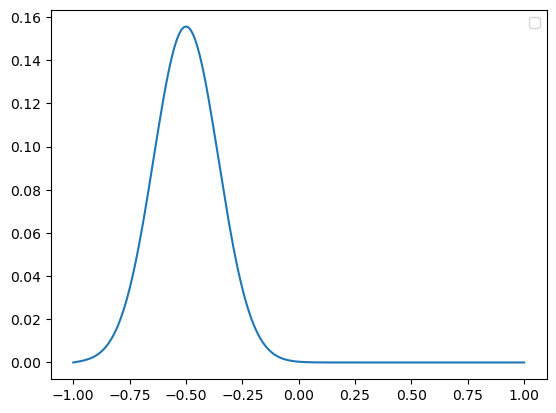

In [7]:
import matplotlib.pyplot as plt
plt.plot(x, T_exp)
plt.legend()
plt.show()

In [ ]:
plt.plot(x, T_imp)
